<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Lane_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

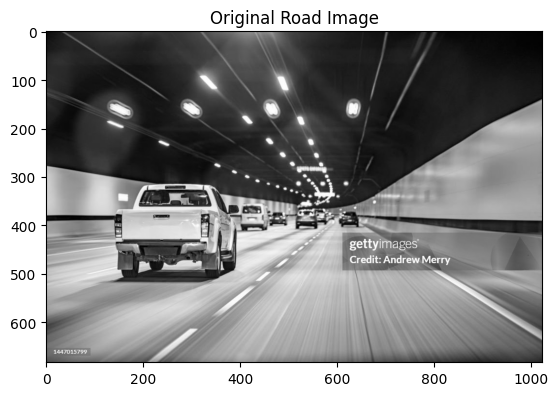

In [4]:
img = cv2.imread("highway.jpg")            # replace with dataset image
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.title("Original Road Image")
plt.show()

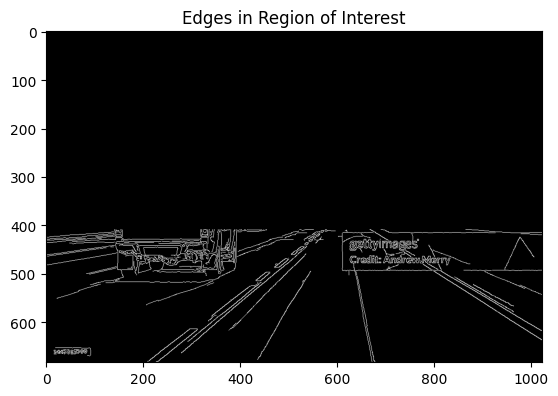

In [5]:
edges = cv2.Canny(gray, 50, 150)

# Define region of interest (ROI)
height, width = edges.shape
mask = np.zeros_like(edges)
polygon = np.array([[
    (0, height),
    (width, height),
    (width, int(height*0.6)),
    (0, int(height*0.6))
]])
cv2.fillPoly(mask, polygon, 255)
masked = cv2.bitwise_and(edges, mask)

plt.imshow(masked, cmap='gray')
plt.title("Edges in Region of Interest")
plt.show()


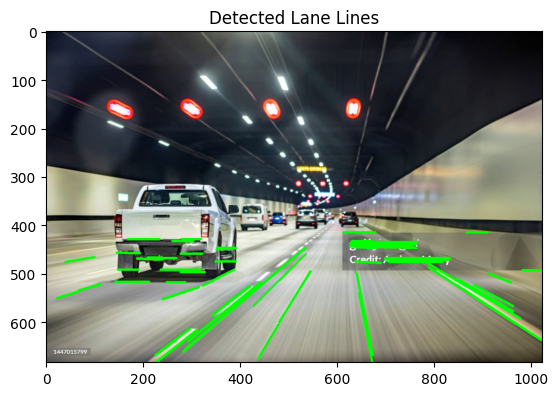

In [6]:
lines = cv2.HoughLinesP(masked, 2, np.pi/180, 100,
                        np.array([]), minLineLength=40, maxLineGap=5)

line_img = np.copy(img)
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Lane Lines")
plt.show()


In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
import cv2
import os
import glob

# Create folders
os.makedirs("data/lane", exist_ok=True)
os.makedirs("data/non_lane", exist_ok=True)

images = glob.glob("highway.jpg")  # folder where your driving images are

def save_patch(img, x, y, label, idx):
    patch = img[y:y+64, x:x+64]
    fname = f"data/{label}/{label}_{idx}.jpg"
    cv2.imwrite(fname, patch)

idx = 0
for path in images:
    img = cv2.imread(path)
    h, w, _ = img.shape

    # random sampling of patches
    for _ in range(50):
        x = np.random.randint(0, w-64)
        y = np.random.randint(0, h-64)

        # simple rule: bright white/yellow pixels → lane
        patch = img[y:y+64, x:x+64]
        if np.mean(patch[:,:,2]) > 180:  # very rough heuristic
            save_patch(img, x, y, "lane", idx)
        else:
            save_patch(img, x, y, "non_lane", idx)
        idx += 1


In [9]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "data/",
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset="training"
)

val_gen = datagen.flow_from_directory(
    "data/",
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset="validation"
)

Found 41 images belonging to 2 classes.
Found 9 images belonging to 2 classes.


In [10]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 555ms/step - accuracy: 0.7436 - loss: 0.6457 - val_accuracy: 1.0000 - val_loss: 0.0977
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9142 - loss: 0.5830 - val_accuracy: 1.0000 - val_loss: 0.1567
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9408 - loss: 0.3524 - val_accuracy: 1.0000 - val_loss: 0.2222
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9200 - loss: 0.4494 - val_accuracy: 1.0000 - val_loss: 0.2216
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9304 - loss: 0.3458 - val_accuracy: 1.0000 - val_loss: 0.1184
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9512 - loss: 0.2927 - val_accuracy: 1.0000 - val_loss: 0.0660
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9200 - loss: 0.3080 - val_accuracy: 1.0000 - val_loss: 0.0925
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9142 - loss: 0.2573 - val_accuracy: 1.0000 - val_loss:

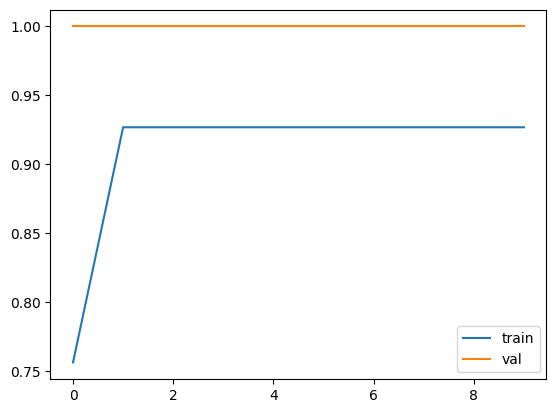

In [11]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

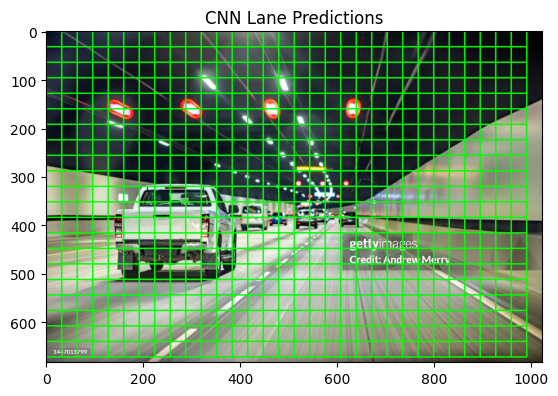

In [12]:
def sliding_window(image, step=32, window_size=64):
    for y in range(0, image.shape[0] - window_size, step):
        for x in range(0, image.shape[1] - window_size, step):
            yield (x, y, image[y:y+window_size, x:x+window_size])

output_img = img.copy()
for (x, y, patch) in sliding_window(img):
    patch_normalized = patch / 255.0
    patch_normalized = np.expand_dims(patch_normalized, axis=0)

    pred = model.predict(patch_normalized)[0][0]

    if pred > 0.5:  # lane
        cv2.rectangle(output_img, (x,y), (x+64, y+64), (0,255,0), 2)

plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("CNN Lane Predictions")
plt.show()

In [13]:
left_lane_history = []
right_lane_history = []

def average_lane(points_list):
    if len(points_list) > 10:
        points_list.pop(0)
    return np.mean(points_list, axis=0)

In [14]:
# cap = cv2.VideoCapture("drive.mp4")
# out = cv2.VideoWriter("output.mp4", cv2.VideoWriter_fourcc(*'XVID'), 20.0, (1280,720))

# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret:
#         break

#     processed = pipeline(frame)  # CNN + Hough + smoothing
#     out.write(processed)

# cap.release()
# out.release()